In [2]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

hep.style.use("ATLAS")

In [8]:
# --- load per-file size/event counts from the lxplus step ---
df = pd.read_csv("event_counts.csv")

label_muon = "Events passing single muon trigger"
label_jet_muon = "Pass muon trig.; Fail jet trig\nMuon TLA + Jet TLA EDM"

# --- pull run number + lumiblock out of the filename ---
def parse_run_lb(filename):
    m = re.search(r"\.(\d{8})\..*_lb(\d+)\.", filename)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

df["basename"] = df["file"].apply(os.path.basename)
parsed = df["basename"].apply(parse_run_lb)
df["run_number"] = parsed.apply(lambda x: x[0])
df["lb"] = parsed.apply(lambda x: x[1])

df["bytes_per_event"] = df["size_bytes"] / df["nevents"]

# --- load the lumi/pileup lookup ---
lumi = pd.read_csv("lumi_lookup_combined.csv")

merged = df.merge(
    lumi[["run", "lb", "mu"]],
    left_on=["run_number", "lb"],
    right_on=["run", "lb"],
    how="left",
)

missing = merged["mu"].isna().sum()
if missing:
    print(f"Warning: {missing} files had no matching lumi/pileup entry")

colors = {"jet_Trig": "#cc6600", "jet_muon_Trig": "#90EE90", "muon_Trig": "#5b9bd5"}
labels = {"muon_Trig": label_muon}

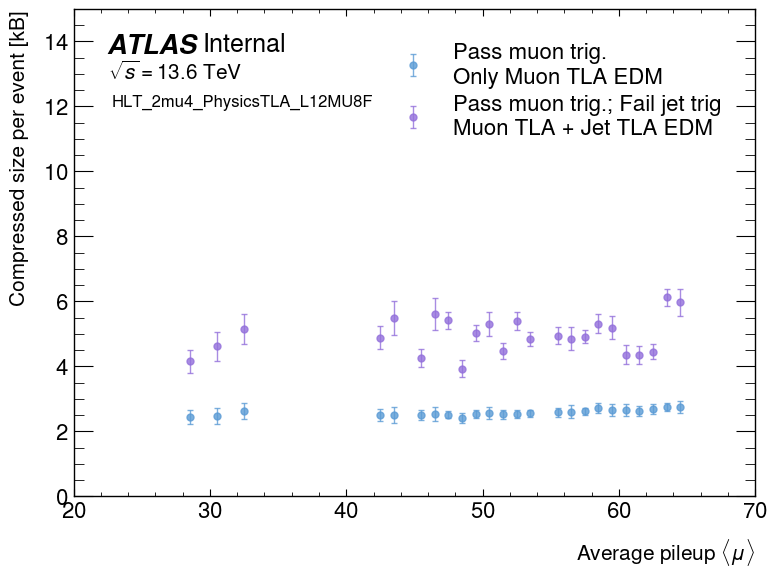

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# --- distinguish the special JetMuonTLA jet_muon_Trig batch from the regular one ---
merged["trigger_label"] = np.where(
    (merged["trigger"] == "jet_muon_Trig") & merged["folder"].str.contains("JetMuonTLA"),
    label_jet_muon,
    merged["trigger"],
)
colors[label_jet_muon] = "#9370DB"  # pick whatever color you like

fig, ax = plt.subplots(figsize=(8, 6))

for trig in ["muon_Trig", label_jet_muon]:
    sub = merged[merged["trigger_label"] == trig].copy()
    sub["mu_bin"] = np.floor(sub["mu"]).astype("Int64")
    binned = (
        sub.dropna(subset=["mu_bin"])
        .groupby("mu_bin")
        .agg(total_bytes=("size_bytes", "sum"),
             total_nevents=("nevents", "sum"),
             n_files=("size_bytes", "size"))
        .reset_index()
    )
    binned = binned[binned["total_nevents"] > 0]

    y = binned["total_bytes"] / binned["total_nevents"] / 1024
    yerr = y / np.sqrt(binned["total_nevents"])

    # --- reject points with relative uncertainty > 20% ---
    rel_err = yerr / y
    mask = rel_err <= 0.2
    binned = binned[mask]
    y = y[mask]
    yerr = yerr[mask]

    lab = trig
    if trig == "muon_Trig":
        lab = "Pass muon trig.\nOnly Muon TLA EDM"

    ax.errorbar(binned["mu_bin"] + 0.5, y, yerr=yerr, fmt="o", label=lab,
                color=colors.get(trig), ecolor=colors.get(trig),
                alpha=0.8, markersize=5, elinewidth=1, capsize=2)

ax.set_xlabel(r"Average pileup $\langle \mu \rangle$", fontsize=15)
ax.set_ylabel("Compressed size per event [kB]", fontsize=15)
ax.tick_params(labelsize=16)
ax.set_ylim(0, 15)
ax.set_xlim(20, 70)
hep.atlas.label(ax=ax, label="Internal", data=True, com=13.6, fontsize=15)

plt.text(0.055, 0.825, 'HLT_2mu4_PhysicsTLA_L12MU8F',
         transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='left',
         fontsize=12)
"""
edm_text = (
    "Containers filling EDM:\n"
    "HLT_MuonsCB_RoI_TLA\n"
    "HLT_IDTrack_Muon_IDTrig"
)

plt.text(0.055, 0.76, edm_text,
         transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='left',
         fontsize=10)
"""
ax.legend(fontsize=16, loc="upper right")
plt.tight_layout()
plt.savefig("jet_problem.pdf")
plt.show()